In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import lightkurve as lk
import glob
import re
from astroquery import vizier

In [5]:
#IDS
#Vetted TIC IDs
tic_id_list = ['257436461', '435339847', '337607207', '39936432', '392469577', '266014079', '14570099', '179032688', '376938120', '187309502', '333605244', '366631954', '307733361', '332022997', '238608004', '376939759', '418761354', '293460551', '12822545', '187960878', '440687723', '175241633', '7059054', '297146957', '38258419', '2621212', '175265494', '293375721', '175194958', '380884458', '187273811', '175290532', '26078330', '195193025', '14635562', '677945', '115072772', '12181371', '741596', '146799150', '90090343', '294319820', '458686847', '423358488', '125060509', '175262071', '113979956', '376936928', '135043332', '14111411', '2521105', '332024125', '434226736', '11023038', '15756231', '12770870', '86130229', '197246627', '422349422', '441907126', '10195089', '335102224',  '396972464', '184914317', '49652731', '301258470', '68504570', '446672575', '291090078', '49040478', '4610830', '428820090', '281731203', '301610040', '175193677', '363445338', '335322931', '363445121', '27039476', '301235044', '323687123', '345063080', '380619414', '436575927', '38064757', '277869696', '397022282', '38087018', '18310799', '281886199', '5882269', '150096001', '456945304', '49462779', '50171060', '388804061', '422487869', '82050863', '363444743', '173090902', '443616612', '392817207', '432247315', '903075188', '61312205']

vetted_periods = [33.122, 20.686, 8.733, 29.429, 17.988, 9.007, 30.178, 24.824, 33.119, 20.866, 26.33, 24.244, 4.263, 9.117, 18.253, 40.0, 33.122, 30.19, 16.414, 16.826, 23.532, 11.113, 10.187, 35.639, 21.761, 15.821, 10.788, 16.23, 17.125, 30.5, 13.625, 40.0, 8.891, 24.244, 33.181, 12.03, 26.855, 26.812, 29.005, 12.677, 23.688, 23.065, 9.179, 14.466, 13.047, 11.457, 35.822, 40.0, 7.056, 25.266, 17.997, 20.239, 1.878, 17.552, 2.844, 17.263, 9.557, 36.182, 28.418, 14.436, 40.0, 40.0, 15.393, 21.954, 23.218, 12.356, 12.226, 7.849, 14.823, 6.28, 12.356, 9.655, 18.794, 11.428, 8.33, 7.698, 15.016, 8.517, 18.132, 7.044, 4.338, 14.053, 6.562, 28.531, 13.341, 7.999, 21.062, 21.062, 14.768, 14.294, 8.854, 36.347, 13.289, 19.057, 17.077, 36.367, 23.366, 36.367, 14.294, 20.009, 9.763, 6.637, 10.868, 21.062, 36.279]

print(len(tic_id_list))
print(len(vetted_periods))

105
105


In [6]:
from collections import defaultdict

# Group periods by TIC ID
id_to_periods = defaultdict(list)
for tic_id, period in zip(tic_id_list, vetted_periods):
    id_to_periods[tic_id].append(period)

# Print only duplicates
print(f"{'TIC ID':<15} {'Periods'}")
print("-" * 40)
for tic_id, periods in id_to_periods.items():
    if len(periods) > 1:
        print(f"{tic_id:<15} {periods}")

TIC ID          Periods
----------------------------------------


Matched 38 out of 128 IDs

EPIC ID           My P_rot  Cat P_rot
--------------------------------------
220241529           33.122     33.390
210363145           20.686     20.310
211611158            8.733     17.300
206119924           29.429     29.830
220696233           33.119     30.040
212554013           24.807     20.280
211359660           24.244     24.990
212088059           18.253     18.900
211770795           30.190     27.320
205916793           16.414     16.680
210838726           23.532     23.790
211897691           10.620     11.190
211818569           10.180     10.410
206159027           21.761     22.150
211913977           10.788     10.860
211529065           17.393     17.100
211969807            9.055     17.530
220522262           30.500     30.110
212555594           13.625     13.610
211916756           24.244     23.850
212006344           33.181     28.150
212828909           14.115     27.480
217941732           26.812     16.810
206026136           12

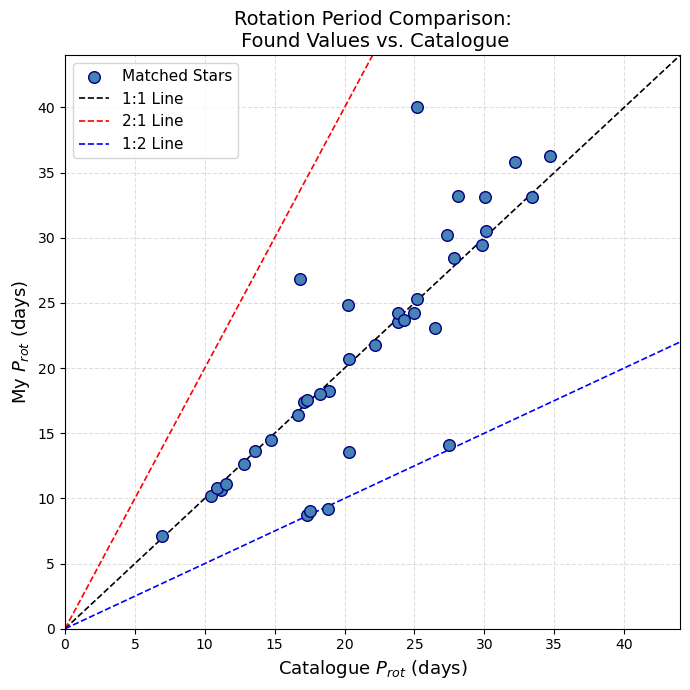

In [16]:
from astroquery.mast import Catalogs
import astropy.units as u

tic_to_epic = {}

for tic_id in tic_id_list:
    # First get coordinates from TIC
    tic_result = Catalogs.query_criteria(catalog="TIC", ID=tic_id)
    
    if len(tic_result) == 0:
        print(f"TIC {tic_id}: not found")
        continue
    
    ra = tic_result['ra'][0]
    dec = tic_result['dec'][0]
    
    # Query EPIC by coordinate box instead of cone
    epic_result = Catalogs.query_criteria(
        catalog="EPIC",
        ra=[ra - 0.001, ra + 0.001],
        dec=[dec - 0.001, dec + 0.001]
    )
    
    if len(epic_result) == 0:
        print(f"TIC {tic_id}: no EPIC match at ({ra:.5f}, {dec:.5f})")
        continue
    
    epic_id = str(epic_result['ID'][0])
    tic_to_epic[tic_id] = epic_id
    print(f"TIC {tic_id} -> EPIC {epic_id}")

print(tic_to_epic)

InvalidQueryError: Criteria query not available for EPIC

In [9]:
from astroquery.mast import Catalogs
import astropy.units as u

epic_to_tic = {}
epic_id_list = ['220241529', '210363145', '211611158', '206119924', '212480208', '220592745', '212132195', '212735333', '220696233', '212554013', '220170303', '211359660', '211990866', '212012119', '212088059', '220504338', '220481411', '211770795', '205916793', '217977895', '210838726', '211897691', '211818569', '212012119', '212499991', '211990866', '206159027', '212779596', '211913977', '211529065', '212132195', '211969807', '220522262', '212555594', '212006318', '210965800', '211916756', '211529065', '212554013', '212006344', '212686205', '212828909', '217941732', '212580872', '206026136', '214173069', '212440430', '211331236', '220194974', '211969807', '216008129', '211970147', '210750726', '220621087', '212768333', '211913977', '210968143', '212756297', '212157262', '212088059', '212828909', '211970147', '210490365', '211969807', '218916923', '211897691', '211529065', '212499991', '210818897', '211970147', '206007892', '251319382', '212072539', '211818569', '212157262', '212072539', '212460519', '211913977', '212088059', '216405287', '212686205', '212768333', '217192839', '212496592', '211897691']

from astroquery.mast import Catalogs, Observations
from astropy.coordinates import SkyCoord
import astropy.units as u

for epic_id in epic_id_list:
    # Format as K2 target name (ktwo + zero-padded 9-digit ID)
    target_name = f"ktwo{int(epic_id):09d}"

    # Get the K2 observation to extract coordinates
    obs = Observations.query_criteria(
        target_name=target_name,
        obs_collection="K2",
        radius=0.0  # exact match only
    )

    if len(obs) == 0:
        print(f"EPIC {epic_id}: no K2 observation found")
        continue

    ra = obs['s_ra'][0]
    dec = obs['s_dec'][0]

    # Now query TIC by coordinate
    tic_result = Catalogs.query_region(
        SkyCoord(ra, dec, unit="deg"),
        catalog="TIC",
        radius=3 * u.arcsec
    )

    if len(tic_result) == 0:
        print(f"EPIC {epic_id}: no TIC match at ({ra:.5f}, {dec:.5f})")
        continue

    # Closest match is first (sorted by dstArcSec)
    tic_id = str(tic_result['ID'][0])
    epic_to_tic[epic_id] = tic_id
    print(f"EPIC {epic_id} -> TIC {tic_id}")

print(epic_to_tic)

EPIC 220241529 -> TIC 257436461
EPIC 210363145 -> TIC 435339847
EPIC 211611158 -> TIC 337607207
EPIC 206119924 -> TIC 39936432
EPIC 212480208 -> TIC 392469577
EPIC 220592745 -> TIC 266014079
EPIC 212132195 -> TIC 14570099
EPIC 212735333 -> TIC 179032688
EPIC 220696233 -> TIC 376938120
EPIC 212554013 -> TIC 187309502
EPIC 220170303 -> TIC 333605244
EPIC 211359660 -> TIC 366631954
EPIC 211990866 -> TIC 307733361
EPIC 212012119 -> TIC 332022997
EPIC 212088059 -> TIC 238608004
EPIC 220504338 -> TIC 376939759
EPIC 220481411 -> TIC 418761354
EPIC 211770795 -> TIC 293460551
EPIC 205916793 -> TIC 12822545
EPIC 217977895 -> TIC 187960878
EPIC 210838726 -> TIC 440687723
EPIC 211897691 -> TIC 175241633
EPIC 211818569 -> TIC 7059054
EPIC 212012119 -> TIC 332022997
EPIC 212499991 -> TIC 297146957
EPIC 211990866 -> TIC 307733361
EPIC 206159027 -> TIC 38258419
EPIC 212779596 -> TIC 2621212
EPIC 211913977 -> TIC 175265494
EPIC 211529065 -> TIC 293375721
EPIC 212132195 -> TIC 14570099
EPIC 211969807 ->

In [11]:
print(len(epic_to_tic))
print(len(epic_id_list))

62
85


In [10]:
new_periods_lookup = {
    '212132195': 30.178, '212554013': 20.866, '211990866': 4.263,
    '212012119': 9.117,  '212088059': 18.253, '211897691': 11.113,
    '211818569': 10.187, '212499991': 35.639, '211913977': 10.788,
    '211529065': 16.23,  '211969807': 17.125, '212686205': 12.03,
    '212828909': 26.855, '211970147': 11.457, '212768333': 7.056,
    '212157262': 20.239, '212072539': 36.182
}

# Step 1: deduplicate, keeping first occurrence
seen = {}
for eid, period in zip(tic_id_list, vetted_periods):
    if eid not in seen:
        seen[eid] = period

print(f"After dedup: {len(seen)} unique IDs (was {len(tic_id_list)} total)")

# Step 2: apply refined periods from lookup table
for eid, new_period in new_periods_lookup.items():
    if eid in seen:
        print(f"  Updating {eid}: {seen[eid]} → {new_period}")
    seen[eid] = new_period

# Step 3: unpack to final parallel lists
final_ids     = list(seen.keys())
final_periods = list(seen.values())

print(f"\nFinal count: {len(final_ids)}")
print("\n{:<15} {}".format("TIC/EPIC ID", "Period"))
print("-" * 30)
for eid, p in zip(final_ids, final_periods):
    print(f"{eid:<15}  {p}")

NameError: name 'tic_id_list' is not defined

In [11]:
from astroquery.mast import Catalogs, Observations
from astropy.coordinates import SkyCoord
import astropy.units as u

epic_to_tic = {}
tics = []

for epic_id in final_ids:
    # Format as K2 target name (ktwo + zero-padded 9-digit ID)
    target_name = f"ktwo{int(epic_id):09d}"

    # Get the K2 observation to extract coordinates
    obs = Observations.query_criteria(
        target_name=target_name,
        obs_collection="K2",
        radius=0.0  # exact match only
    )

    if len(obs) == 0:
        print(f"EPIC {epic_id}: no K2 observation found")
        continue

    ra = obs['s_ra'][0]
    dec = obs['s_dec'][0]

    # Now query TIC by coordinate
    tic_result = Catalogs.query_region(
        SkyCoord(ra, dec, unit="deg"),
        catalog="TIC",
        radius=3 * u.arcsec
    )

    if len(tic_result) == 0:
        print(f"EPIC {epic_id}: no TIC match at ({ra:.5f}, {dec:.5f})")
        continue


    # Closest match is first (sorted by dstArcSec)
    tic_id = str(tic_result['ID'][0])
    epic_to_tic[epic_id] = tic_id
    tics.append(tic_id)
    print(f"EPIC {epic_id} -> TIC {tic_id}")

print(epic_to_tic)

NameError: name 'final_ids' is not defined

In [13]:
print(tics)
print(final_periods)

['257436461', '435339847', '337607207', '39936432', '392469577', '266014079', '14570099', '179032688', '376938120', '187309502', '333605244', '366631954', '307733361', '332022997', '238608004', '376939759', '418761354', '293460551', '12822545', '187960878', '440687723', '175241633', '7059054', '297146957', '38258419', '2621212', '175265494', '293375721', '175194958', '380884458', '187273811', '175290532', '26078330', '195193025', '14635562', '677945', '115072772', '12181371', '741596', '146799150', '90090343', '294319820', '458686847', '423358488', '125060509', '175262071', '113979956', '376936928', '135043332', '14111411', '2521105', '332024125', '434226736', '11023038', '15756231', '12770870', '86130229', '197246627', '422349422', '441907126', '10195089', '335102224']
[33.122, 20.686, 8.733, 29.429, 17.988, 9.007, 30.178, 24.824, 33.119, 20.866, 26.33, 24.244, 4.263, 9.117, 18.253, 40.0, 33.122, 30.19, 16.414, 16.826, 23.532, 11.113, 10.187, 35.639, 21.761, 15.821, 10.788, 16.23, 17.

In [11]:
print(final_ids)

['220241529', '210363145', '211611158', '206119924', '212480208', '220592745', '212132195', '212735333', '220696233', '212554013', '220170303', '211359660', '211990866', '212012119', '212088059', '220504338', '220481411', '211770795', '205916793', '217977895', '210838726', '211897691', '211818569', '212499991', '206159027', '212779596', '211913977', '211529065', '211969807', '220522262', '212555594', '212006318', '210965800', '211916756', '212006344', '212686205', '212828909', '217941732', '212580872', '206026136', '214173069', '212440430', '211331236', '220194974', '216008129', '211970147', '210750726', '220621087', '212768333', '210968143', '212756297', '212157262', '210490365', '218916923', '210818897', '206007892', '251319382', '212072539', '212460519', '216405287', '217192839', '212496592', '396972464', '184914317', '49652731', '301258470', '68504570', '446672575', '291090078', '49040478', '4610830', '428820090', '281731203', '301610040', '175193677', '363445338', '335322931', '36

In [2]:
final_tic_converted = ['257436461', '435339847', '337607207', '39936432', '392469577', '266014079', '14570099', '179032688', '376938120', '187309502', '333605244', '366631954', '307733361', '332022997', '238608004', '376939759', '418761354', '293460551', '12822545', '187960878', '440687723', '175241633', '7059054', '297146957', '38258419', '2621212', '175265494', '293375721', '175194958', '380884458', '187273811', '175290532', '26078330', '195193025', '14635562', '677945', '115072772', '12181371', '741596', '146799150', '90090343', '294319820', '458686847', '423358488', '125060509', '175262071', '113979956', '376936928', '135043332', '14111411', '2521105', '332024125', '434226736', '11023038', '15756231', '12770870', '86130229', '197246627', '422349422', '441907126', '10195089', '335102224',  '396972464', '184914317', '49652731', '301258470', '68504570', '446672575', '291090078', '49040478', '4610830', '428820090', '281731203', '301610040', '175193677', '363445338', '335322931', '363445121', '27039476', '301235044', '323687123', '345063080', '380619414', '436575927', '38064757', '277869696', '397022282', '38087018', '18310799', '281886199', '5882269', '150096001', '456945304', '49462779', '50171060', '388804061', '422487869', '82050863', '363444743', '173090902', '443616612', '392817207', '432247315', '903075188', '61312205']


final_periods = [33.122, 20.686, 8.733, 29.429, 17.988, 9.007, 30.178, 24.824, 33.119, 20.866, 26.33, 24.244, 4.263, 9.117, 18.253, 40.0, 33.122, 30.19, 16.414, 16.826, 23.532, 11.113, 10.187, 35.639, 21.761, 15.821, 10.788, 16.23, 17.125, 30.5, 13.625, 40.0, 8.891, 24.244, 33.181, 12.03, 26.855, 26.812, 29.005, 12.677, 23.688, 23.065, 9.179, 14.466, 13.047, 11.457, 35.822, 40.0, 7.056, 25.266, 17.997, 20.239, 1.878, 17.552, 2.844, 17.263, 9.557, 36.182, 28.418, 14.436, 40.0, 40.0, 15.393, 21.954, 23.218, 12.356, 12.226, 7.849, 14.823, 6.28, 12.356, 9.655, 18.794, 11.428, 8.33, 7.698, 15.016, 8.517, 18.132, 7.044, 4.338, 14.053, 6.562, 28.531, 13.341, 7.999, 21.062, 21.062, 14.768, 14.294, 8.854, 36.347, 13.289, 19.057, 17.077, 36.367, 23.366, 36.367, 14.294, 20.009, 9.763, 6.637, 10.868, 21.062, 36.279]

In [3]:
print(len(final_tic_converted))
print(len(final_periods))

105
105


Matched 0 out of 105 IDs

EPIC ID           My P_rot  Cat P_rot
--------------------------------------


ValueError: max() arg is an empty sequence

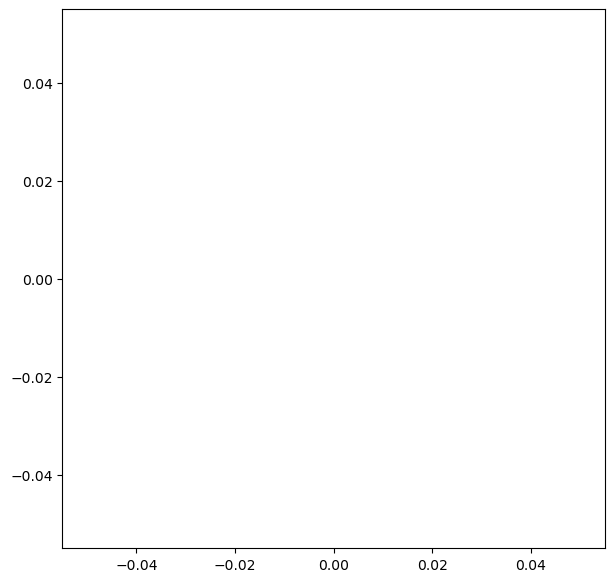

In [20]:
import pandas as pd
import matplotlib.pyplot  as plt

vetted_dict = dict(zip(final_tic_converted, final_periods))

df = pd.read_csv(
    '/Users/iansterrett/Downloads/k2_nominal_prot.tsv',
    sep=';',
    comment='#',
    skipinitialspace=True
)

df.columns = df.columns.str.strip()
df = df[~df['EPIC'].astype(str).str.contains('-')]  # remove separator rows
df['EPIC'] = df['EPIC'].astype(str).str.strip()
df['Prot'] = pd.to_numeric(df['Prot'], errors='coerce')

matched_ids = []
my_periods = []
cat_periods = []

for epic_id, my_prot in vetted_dict.items():
    match = df[df['EPIC'] == epic_id]
    if not match.empty and not pd.isna(match['Prot'].values[0]):
        matched_ids.append(epic_id)
        my_periods.append(my_prot)
        cat_periods.append(match['Prot'].values[0])

print(f"Matched {len(matched_ids)} out of {len(final_tic_converted)} IDs")
print(f"\n{'EPIC ID':<15} {'My P_rot':>10} {'Cat P_rot':>10}")
print("-" * 38)
for eid, mp, cp in zip(matched_ids, my_periods, cat_periods):
    print(f"{eid:<15} {mp:>10.3f} {cp:>10.3f}")


fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(cat_periods, my_periods, color='steelblue', edgecolors='navy', s=70, zorder=3, label='Matched Stars')

all_vals = my_periods + cat_periods
lim = (0, max(all_vals) * 1.1)
ax.plot(lim, lim, 'k--', linewidth=1.2, label='1:1 Line', zorder=2)
ax.plot(lim, [x * 2 for x in lim], 'r--', linewidth=1.2, label='2:1 Line', zorder=2)
ax.plot(lim, [x * 0.5 for x in lim], 'b--', linewidth=1.2, label='1:2 Line', zorder=2)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Catalogue $P_{rot}$ (days)', fontsize=13)
ax.set_ylabel('My $P_{rot}$ (days)', fontsize=13)
ax.set_title('Rotation Period Comparison:\n Found Values vs. Catalogue', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/prot_comparison.png', dpi=150)
print("\nPlot saved to prot_comparison.png")

In [21]:
import pandas as pd
from astroquery.mast import Catalogs

def get_coords_from_tic(tic_ids):
    """
    Queries MAST to get RA and Dec for a list of TIC IDs.
    """
    # Ensure IDs are strings for the query
    tic_ids = [str(tid) for tid in tic_ids]
    
    print(f"Querying MAST for {len(tic_ids)} IDs...")
    
    # Query the TIC catalog
    # 'ID' in query_criteria refers to the TIC ID
    result_table = Catalogs.query_criteria(catalog="TIC", ID=tic_ids)
    
    # Convert to pandas for easier manipulation
    df_coords = result_table.to_pandas()
    
    # Select only the essential columns
    # 'ra' and 'dec' are J2000 coordinates
    df_coords = df_coords[['ID', 'ra', 'dec']]
    df_coords.columns = ['TIC_ID', 'RA', 'Dec']
    
    return df_coords

coord_df = get_coords_from_tic(final_tic_converted)

print("\nResults:")
print(coord_df)

# To use these in your existing cross-match dictionary:
# ra_dict = dict(zip(coord_df['TIC_ID'].astype(int), coord_df['RA']))
# dec_dict = dict(zip(coord_df['TIC_ID'].astype(int), coord_df['Dec']))

Querying MAST for 105 IDs...

Results:
        TIC_ID          RA        Dec
0    125060509  293.560726 -23.131101
1    175194958  129.636817  19.773775
2    293375721  131.266611  13.549830
3    175193677  129.689668  23.685906
4     10195089  288.026922 -21.007641
..         ...         ...        ...
100   18310799   67.412474  22.882721
101  436575927   71.109826  16.518680
102   14570099  125.987074  22.663038
103  363444743  169.483616   5.988393
104  293460551  132.009733  16.901863

[105 rows x 3 columns]


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.mast import Catalogs

# 1. --- Prepare Catalogue Data (long2023.tsv) ---
# Note: Use sep='\t' for TSV files
df_cat = pd.read_csv('/Users/iansterrett/Downloads/oelkers2018.tsv', sep='\t', comment='#', skipinitialspace=True)
df_cat.columns = df_cat.columns.str.strip()

# Ensure the columns are numeric. 
# Errors='coerce' turns text like "deg" or "---" into NaN.
df_cat['RAJ2000'] = pd.to_numeric(df_cat['RAJ2000'], errors='coerce')
df_cat['DEJ2000'] = pd.to_numeric(df_cat['DEJ2000'], errors='coerce')
df_cat['Prot'] = pd.to_numeric(df_cat['Prot'], errors='coerce')

# Drop rows that don't have RA, Dec, OR a Rotation Period
df_cat = df_cat.dropna(subset=['RAJ2000', 'DEJ2000', 'Prot'])

print(f"Catalog stars with valid periods: {len(df_cat)}")

if len(df_cat) == 0:
    raise ValueError("The catalog is empty after cleaning. Check if the column names 'RAJ2000', 'DEJ2000', and 'Prot' match your file exactly.")

catalog_coords = SkyCoord(ra=df_cat['RAJ2000'].values*u.degree, 
                          dec=df_cat['DEJ2000'].values*u.degree, 
                          frame='icrs')

# 2. --- Fetch Coordinates for your TIC IDs ---
print(f"Querying MAST for {len(final_tic_converted)} TIC IDs...")
tic_ids_str = [str(tid) for tid in final_tic_converted]
result_table = Catalogs.query_criteria(catalog="TIC", ID=tic_ids_str)
coord_df = result_table.to_pandas()[['ID', 'ra', 'dec']]

# Map IDs to Coordinates
coord_map = {int(row['ID']): (row['ra'], row['dec']) for _, row in coord_df.iterrows()}

my_ra, my_dec, valid_periods = [], [], []
for tid, period in zip(final_tic_converted, final_periods):
    if tid in coord_map:
        ra, dec = coord_map[tid]
        my_ra.append(ra)
        my_dec.append(dec)
        valid_periods.append(period)

if len(my_ra) == 0:
    print("Warning: No matching coordinates found in MAST for your TIC IDs.")
else:
    my_coords = SkyCoord(ra=my_ra*u.degree, dec=my_dec*u.degree, frame='icrs')

    # 3. --- Perform Spatial Cross-Match ---
    # idx: indices into catalog_coords; d2d: separation distance
    idx, d2d, _ = my_coords.match_to_catalog_sky(catalog_coords)

    # Filter by a 1 arcsecond threshold
    max_sep = 1.0 * u.arcsec
    mask = d2d < max_sep

    matched_my_periods = [valid_periods[i] for i, is_match in enumerate(mask) if is_match]
    matched_cat_periods = df_cat.iloc[idx[mask]]['Prot'].values

    print(f"Successfully matched {len(matched_my_periods)} stars within {max_sep}")

    # 4. --- Plotting ---
    if len(matched_my_periods) > 0:
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.scatter(matched_cat_periods, matched_my_periods, 
                   color='steelblue', edgecolors='navy', s=70, zorder=3, label='Matched Stars')

        # Axis limits and helper lines
        all_vals = list(matched_my_periods) + list(matched_cat_periods)
        lim = (0, max(all_vals) * 1.1)
        ax.plot(lim, lim, 'k--', linewidth=1.2, label='1:1 Line')
        ax.plot(lim, [x * 2 for x in lim], 'r--', linewidth=1.2, label='2:1 Line (Harmonic)')
        ax.plot(lim, [x * 0.5 for x in lim], 'b--', linewidth=1.2, label='1:2 Line (Harmonic)')

        ax.set_xlabel('Catalogue $P_{rot}$ (Long+ 2023) [days]')
        ax.set_ylabel('My $P_{rot}$ [days]')
        ax.set_title('Rotation Period Comparison')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
    else:
        print("No spatial matches found between your stars and the catalog within the distance threshold.")

/var/folders/jz/cvbrymkd6v93f1r586w13g7c0000gn/T/ipykernel_11737/628816336.py:9: DtypeWarning: Columns (1,2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cat = pd.read_csv('/Users/iansterrett/Downloads/oelkers2018.tsv', sep='\t', comment='#', skipinitialspace=True)


KeyError: 'Prot'